In [2]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
import os
import glob
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [6]:
#Functions that are common to both the multi file and single file analysis 

def SortByTime(array):
    sorted_array = array[np.argsort(array[:,5])]
    return(sorted_array)

def SortByNN(array):
    sorted_array = array[np.argsort(array[:,0])]
    return(sorted_array)

#returns an array which contains total merged hits, PEs, for each neutrino event, used for creating metrics.
def ReturnNeutrinoInfoArray(time_sorted_hits, number_of_neutrinos):
    
    neutrino_PE_array_merged = np.zeros((number_of_neutrinos, 3))
    for i in range(number_of_neutrinos):
        PEs = 0.
        sub_array = time_sorted_hits[time_sorted_hits[:, 0] == i]
        n_hits = 0
        for hit in sub_array:
            n_hits += 1
            PEs += hit[6]
        neutrino_PE_array_merged[i][0] = i
        neutrino_PE_array_merged[i][1] = PEs
        neutrino_PE_array_merged[i][2] = n_hits

    return(neutrino_PE_array_merged)
#this function checks how many total events were placed into groups. 
def ValidateEvents(events, hit_array_merged):
    hits_sliced = 0
    for group in events:
        for hit in group:
            hits_sliced += 1
    missing = (np.shape(hit_array_merged)[0] - hits_sliced)
    missing_ratio = missing / np.shape(hit_array_merged)[0]
    print(f"Grouped {hits_sliced} hits into {len(events)} slices, {missing} hits were not grouped, {(missing_ratio * 100):2f}% of total")
    return(hits_sliced, missing, missing_ratio)

            
#This function can print out the time slices, caution it prints a lot lol
def SlicerPrinting(events, loud = False):
    print(f"Detected {len(events)} slices:")
    for i, event in enumerate(events):
        print(f"\n--- Event {i+1} ---")
        total_energy_event = sum(hit_row[6] for hit_row in event) # Sum energy from full rows
        print(f"Total hits: {len(event)}")
        print(f"Total energy: {total_energy_event:.2f}")
        # Get min/max time from the full hit rows in the event
        if event: # Ensure event is not empty before accessing elements
            start_time = min(hit_row[5] for hit_row in event)
            end_time = max(hit_row[5] for hit_row in event)
            print(f"Time range: {start_time:.1f} ns - {end_time:.1f} ns")
            print(f"Total time: {(end_time - start_time):.2f} ns")
            
        if loud:
            print("Hits (full data) in event:")
            for hit_row in event:
                # Print specific fields for clarity, or the whole row
                print(f"  Neutrino: {hit_row[0]}, Hit: {hit_row[1]}, Time: {hit_row[5]:.1f}, Energy: {hit_row[6]:.1f}, X: {hit_row[2]}")

def SliceEvaluate(slice_stack, number_of_neutrinos, neutrino_PE_array_merged):
    #make sure you are careful about how assigning here, 
    containment_array = np.zeros((number_of_neutrinos,5))
    #containment_array = np.full((5978,5), -1.) #here, I am assigning -1, will tell us if the neutrino event is just never picked up by the slicer. 
    #if we filled with zeroes could mistake for something that was picked up but at very low efficiency %, a different thing!!

    containment_array = np.zeros((number_of_neutrinos,5)) #|nn | hit containment | PE containment | best hit containment slice | best PE containment slice |
    purity_array = np.zeros((len(slice_stack),2))

    for i in range(number_of_neutrinos):
        containment_array[i][0] = i

    for j in range(len(slice_stack)):
        slice_number = j
        selected_slice = slice_stack[j]
        nns = selected_slice[:,0] #grab the neutrino numbers
        nns_represented, counts = np.unique(nns, return_counts = True) #counts can be used to determine the hit containment, need to loop for PEs

        #fill purity array
        purity_array[slice_number][0] = slice_number
        purity_array[slice_number][1] = len(nns_represented) #fill our purity array with number of unique neutrino numbers in the slice. 
    
        for i, nn in enumerate(nns_represented):
            total_hits = neutrino_PE_array_merged[int(nn)][2] #total hits
            total_PEs = neutrino_PE_array_merged[int(nn)][1] #total PE
            hits_in_slice = counts[i] #hits in this slice
            filtered_rows = (slice_stack[slice_number][slice_stack[slice_number][:, 0] == nn]) #grab subarray of rows with our hits
            PEs_in_slice = np.sum(filtered_rows[:,6]) #sum all the PEs for this nn in the slice. 

            #print(f"Expect {total_hits}, we have {hits_in_slice}")
        
            containment_array[int(nn)][0] = nn #neutrino_number
        
            if (containment_array[int(nn)][1]) <= (hits_in_slice / total_hits) :
                containment_array[int(nn)][1] = hits_in_slice / total_hits #hits contained
                containment_array[int(nn)][3] = slice_number

            if (containment_array[int(nn)][2]) <= (PEs_in_slice / total_PEs) :
                containment_array[int(nn)][2] = PEs_in_slice / total_PEs #PEs contained
                containment_array[int(nn)][4] = slice_number #this slice. 

    #Create a masked version of the array
    neutrinos_with_TMS_hits = np.where(neutrino_PE_array_merged[:, 2] != 0)[0] #check that number of hits is non-zero
    masked_containment_array = containment_array[neutrinos_with_TMS_hits]

    #return containment, masked containment, and purity. 
    return(containment_array, masked_containment_array, purity_array)

def TimePlot(slice_stack, slices_to_grab, init_thresh, drop_thresh):
    slices_grabbed = slice_stack[:slices_to_grab]
    for time_slice in slices_grabbed:
        plt.hist(time_slice[:,5])

    plt.title(f"First {slices_to_grab} Slices - Init Thresh {init_thresh} PE, Drop Thresh {drop_thresh} PE ")
    plt.xlabel("Hit Time (ns)")
    plt.ylabel("# hits")
    plt.show()

def UnpackRoot(time_slices):
    n_slices = time_slices.num_entries
    all_slices = []
    for i in range(n_slices): #range(n_slices):
        arrays = time_slices.arrays()[i]
        hits_in_slice = arrays['n']
        # Pull each field (these are variable-length arrays per slice)
        nns = arrays['neutrino number']
        hns = arrays['hit number']
        xs  = arrays['hit x']
        ys  = arrays['hit y']
        zs  = arrays['hit z']
        ts  = arrays['hit time']
        PEs = arrays['hit PE']
        ors = arrays['bar orientation']
    
        # Stack into a 2D array for this slice: shape (n_hits_in_slice, 8)
        horiz = np.column_stack([
            ak.to_numpy(nns),
            ak.to_numpy(hns),
            ak.to_numpy(xs),
            ak.to_numpy(ys),
            ak.to_numpy(zs),
            ak.to_numpy(ts),
            ak.to_numpy(PEs),
            ak.to_numpy(ors)
        ])
    
        all_slices.append(horiz)

    return(all_slices)

#This function will make clusters with DBSCAN
def MakeClustersDBSCAN(slice_list, selected_slice = 0, MinCluster = 6, Epsilon = 0.1, plot = False):
    nns = slice_list[selected_slice][:,0]
    #hit_ns = slice_list[selected_slice][:,1]
    hit_xs = slice_list[selected_slice][:,2]
    hit_zs = slice_list[selected_slice][:,4]
    hit_ts = slice_list[selected_slice][:,5]
    #hit_PEs = slice_list[selected_slice][:,6]
    pileup = len(np.unique(nns))

    unique_vals, inverse = np.unique(nns, return_inverse=True)

    # Map to 1-based index
    mapped = inverse + 1
    hit_nns_mapped = mapped

    #If we have hits with unique x,z,t positions we should normalize, if not we shouldn't and then need to update epsilon

    #Case where normalization is appropriate
    if len(np.unique(hit_xs)) > 1 and len(np.unique(hit_zs)) > 1 and len(np.unique(hit_ts)) > 1 :
        #Lets normalize x
        min_x = min(hit_xs)
        max_x = max(hit_xs)
        x_range = max_x - min_x
        normalized_xs = (hit_xs + abs(min_x)) / x_range

        #Normalize z
        min_z = min(hit_zs)
        max_z = max(hit_zs)
        z_range = max_z - min_z
        normalized_zs = (hit_zs - min_z) / (z_range)

        #Normalize t (this won't work for negative t I don't think..)
        min_t = min(hit_ts)
        max_t = max(hit_ts)
        t_range = max_t - min_t
        normalized_ts = (hit_ts - min_t) / (t_range)

        norm_hit_vecs = []
        for i in range(len(normalized_xs)):
            norm_hit_vec = [normalized_zs[i], normalized_xs[i], normalized_ts[i]]
            norm_hit_vecs.append(norm_hit_vec)

        norm_hit_vec_array = np.array(norm_hit_vecs)

        #perform clustering
        db_clusters = DBSCAN(eps = Epsilon, min_samples = MinCluster).fit(norm_hit_vec_array)

    #Case where we need to not normalize!
    else:
        #print(f"Had to use non-normalized clustering for slice {selected_slice}")
        hit_vecs = []
        for i in range(len(hit_xs)):
            hit_vec = [hit_zs[i], hit_xs[i], hit_ts[i]]
            hit_vecs.append(hit_vec)
            
        hit_vec_array = np.array(hit_vecs)
        db_clusters = DBSCAN(eps = 250, min_samples = MinCluster).fit(hit_vec_array)

    if (plot == True):
        #plotting 
        print("Outputting comparison plots")
              
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 6))

        sc1 = ax1.scatter(hit_zs, hit_xs, s = 4, c = hit_nns_mapped , cmap = 'nipy_spectral')
        fig.colorbar(sc1, ax=ax1, label = 'Neutrino Interaction')
        ax1.set_title(f"Time Slice {selected_slice}, {len(np.unique(nns))} Interactions, By NN")
        ax1.set_xlabel("Hit Z (mm)")
        ax1.set_ylabel("Hit X (mm)")

        sc2 = ax2.scatter(hit_zs, hit_xs, s = 4, c = db_clusters.labels_, cmap = 'nipy_spectral')
        fig.colorbar(sc2, ax=ax2, label = 'Cluster # (-1, outlier)')
        ax2.set_title(f"Time Slice {selected_slice}, {len(np.unique(nns))} Interactions, By DBSCAN Cluster")
        ax2.set_xlabel("Hit Z (mm)")
        ax2.set_ylabel("Hit X (mm)")

    #Add the clusters to our slice info.

    clusters_added = np.column_stack((slice_list[selected_slice], db_clusters.labels_))

    return(clusters_added)

    #this outputs a time slice, will need to stack with others to get the slice stack back together. 

def EpsilonTest(slice_list, selected_slice = 0):
    hit_xs = slice_list[selected_slice][:,2]
    hit_zs = slice_list[selected_slice][:,4]
    hit_ts = slice_list[selected_slice][:,5]

    x_ranges = []
    z_ranges = []
    t_ranges = []
    
    if len(np.unique(hit_xs)) > 1 and len(np.unique(hit_zs)) > 1 and len(np.unique(hit_ts)) > 1 :
        #Lets normalize x
        min_x = min(hit_xs)
        max_x = max(hit_xs)
        x_range = max_x - min_x
        x_ranges.append(x_range)
        normalized_xs = (hit_xs + abs(min_x)) / x_range

        #Normalize z
        min_z = min(hit_zs)
        max_z = max(hit_zs)
        z_range = max_z - min_z
        z_ranges.append(z_range)
        normalized_zs = (hit_zs - min_z) / (z_range)

        #Normalize t (this won't work for negative t I don't think..)
        min_t = min(hit_ts)
        max_t = max(hit_ts)
        t_range = max_t - min_t
        t_ranges.append(t_range)
        normalized_ts = (hit_ts - min_t) / (t_range)

    return(x_ranges, z_ranges, t_ranges)
    

        

def FullFileCluster(slice_list_, MinCluster_ = 6, Epsilon_ = 0.1): #this will run clustering on the whole file!
    n_slices = len(slice_list_) #This is the number of time slices
    slice_container = []
    for i in range(n_slices):
        clustered_slice = MakeClustersDBSCAN(slice_list_, selected_slice = i, MinCluster = MinCluster_, Epsilon = Epsilon_, plot = False)
        slice_container.append(clustered_slice)

    #now just return the list with the added cluster information!
    return(slice_container)

#Quite similar to SliceEvaluate, this function will output a containment array and a masked containment array. 
def ClusterEvaluate(slice_list_clustered_, neutrino_truth_array, number_of_neutrinos):
    #We can define a containment array, will be looping over both slices and clusters and checking for the best cluster!
    containment_array = np.zeros((number_of_neutrinos,7)) #|nn | hit containment | PE containment | best hit containment slice | best hit containment cluster | best PE containment slice | best PE containment cluster |
    #Initialize with nns
    for i in range(number_of_neutrinos):
        containment_array[i][0] = i

    cluster_occupancy = []

    #Big nested loop coming up
    #Loop over each slice
    for i, slice_ in enumerate(slice_list_clustered_) :
        #Now we need to identify the clusters:
        cluster_numbers = np.unique(slice_[:,-1]) #grab the cluster numbers
        for cluster_number in cluster_numbers:
            cluster_sub_array = slice_[ slice_[:,-1] == cluster_number ] #this is an array of all the hits in a given cluster. 
            #now do a grouping by neutrino number
            nns_in_cluster = np.unique(cluster_sub_array[:,0])
            cluster_occupancy.append(len(nns_in_cluster))
            #now loop over the neutrino numbers
            for nn in nns_in_cluster:
                nn_sub_array = cluster_sub_array[ cluster_sub_array[:,0] == nn ]  #array of hits in a cluster with a given neutrino number
                #Grab truth information for this neutrino number
                total_PEs = neutrino_truth_array[int(nn)][1] #total PE
                total_hits = neutrino_truth_array[int(nn)][2] #total hits
                cluster_PE = np.sum(nn_sub_array[:,6])
                cluster_hits = np.shape(nn_sub_array)[0]

                if (containment_array[int(nn)][1]) <= (cluster_hits / total_hits) :
                    containment_array[int(nn)][1] = cluster_hits / total_hits #hits contained
                    containment_array[int(nn)][3] = i #slice
                    containment_array[int(nn)][4] = cluster_number #cluster number within slice

                if (containment_array[int(nn)][2]) <= (cluster_PE / total_PEs) :
                    containment_array[int(nn)][2] = cluster_PE / total_PEs #PEs contained
                    containment_array[int(nn)][5] = i #this slice. 
                    containment_array[int(nn)][6] = cluster_number #cluster number within slice

    #apply a masking such that we are only reviewing neutrino events with tms hits
    neutrinos_with_TMS_hits = np.where(neutrino_truth_array[:, 2] != 0)[0] #check that number of hits is non-zero
    masked_containment_array = containment_array[neutrinos_with_TMS_hits]

    return(containment_array, masked_containment_array, cluster_occupancy) #now we return both arrays  

In [4]:
#Load in the files that we need:
#Sadly we need to load in the original edep-sim file to do any analysis that involves information about the origin neutrino (ie, if the track is a muon etc.) This ofc would have been too much to drag along through whole series. 
edep_file = root.TFile("/sdf/data/neutrino/summer25/tanaka/nd-production/run-spill-build/MicroProdN4p1_NDComplex_FHC.spill.full/EDEPSIM_SPILLS/0002000/0002500/MicroProdN4p1_NDComplex_FHC.spill.full.0002500.EDEPSIM_SPILLS.root") #grab the edep-sim file, can pull neutrino vertex information as well as event characteristics
edep_detsim = edep_file.Get("DetSimPassThru") #grab detsim, should contain the gRooTracker
edep_events = edep_file.Get("EDepSimEvents") #grab events, mostly for the trajectories (can help characterize the event)
gRooTrackerTree = edep_detsim.gRooTracker #the gRooTracker contains neutrino vertex information
#Pull the merged events
merged_hits_file = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/mulithit_detector_sim_lossy_2500.npz') #grab merged hits for the file, not time sliced - some destination in /sdf/data/neutrino/summer25/ktwall/tms_timing/multihit
merged_hits_array = merged_hits_file['first']
n_neutrino_events = merged_hits_file['second']
#Pull the actual time slices
time_slice_file = uproot.open(" /sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2500_sliced_init-8.0_drop-4.0.root") #grab the time slice output
time_slices = time_slice_file['Time Slices']
basic_metrics = time_slice_file['Metrics']

In [5]:
#Let's unpack the time slices into a format friendly for our functions, namely:
# an ordered list of time slice arrays, containing rows with the following column format: collective_neutrino_number, collective_hit_number, bar_x, bar_y, bar_z, collective_time, total_pe, bar_orientation_code
slice_list = UnpackRoot(time_slices)

In [35]:
x_s = []
t_s = []
z_s = []
for i, slice in enumerate(slice_list):
    x_ranges_ , z_ranges_, t_ranges_ = EpsilonTest(slice_list, selected_slice = i)
    if len(x_ranges_) > 0 and len(z_ranges_) > 0 and len(t_ranges_) > 0 : 
        x_s.append(36.0 / x_ranges_[0])
        z_s.append(96.0 / z_ranges_[0])
        t_s.append(t_ranges_[0])
        
mean_delta_x = np.mean(x_s)
mean_delta_z = np.mean(z_s)
print(mean_delta_x)
print(mean_delta_z)
#some desmos calculations
corrected_t = []
problematic = []
for i, t in enumerate(t_s):
    corrected_t.append(t*0.3)
    if (t*0.3) < 4:
        problematic.append(t*0.3)
problematic

0.017364893104950575
0.037861902367900914


[np.float64(2.5466018390141016),
 np.float64(1.7314718952196926),
 np.float64(1.3019432544708252),
 np.float64(2.797882318496704),
 np.float64(0.45557384490966796),
 np.float64(1.7740187644958496),
 np.float64(3.3856587409973145),
 np.float64(0.05894050598144531),
 np.float64(0.5775647163391113),
 np.float64(3.927198886871338),
 np.float64(1.0748099327087401),
 np.float64(2.322517490386963),
 np.float64(2.3065835952758786),
 np.float64(1.7368600845336915),
 np.float64(1.7596275329589843),
 np.float64(2.902782440185547),
 np.float64(1.0831312179565429),
 np.float64(1.962110137939453),
 np.float64(3.4208604812622068),
 np.float64(3.2122936248779297),
 np.float64(1.3485700607299804),
 np.float64(1.8334367752075194),
 np.float64(0.2486715316772461),
 np.float64(0.5048681259155273),
 np.float64(1.4849132537841796)]

In [26]:
%%time 
#Let's do a quick study of the "volatility" of epsilon choice. Treat MinCluster as fixed - by rule of thumb.
avg_hit_eff = []
avg_PE_eff = []
avg_occupancy = []

hit_eff_all = []
PE_eff_all = []
occupancy_all = []

epsilons = np.arange(1,21) / 100
for eps in epsilons:
    slice_list_clustered = FullFileCluster(slice_list_ = slice_list, MinCluster_ = 6, Epsilon_ = eps)
    neutrino_truth_array = ReturnNeutrinoInfoArray(SortByTime(merged_hits_array), n_neutrino_events) #create a truth array
    unmasked_cluster_eval, masked_cluster_eval, cluster_occupancy = ClusterEvaluate(slice_list_clustered, neutrino_truth_array, n_neutrino_events)
    hit_eff_all.append(masked_cluster_eval[:,1])
    PE_eff_all.append(masked_cluster_eval[:,2])
    occupancy_all.append(cluster_occupancy)
    avg_hit_eff.append(np.mean(masked_cluster_eval[:,1]))
    avg_PE_eff.append(np.mean(masked_cluster_eval[:,2]))
    avg_occupancy.append(np.mean(cluster_occupancy))

CPU times: user 1min 59s, sys: 418 ms, total: 2min
Wall time: 1min 38s


Text(0, 0.5, 'Interactions / Cluster')

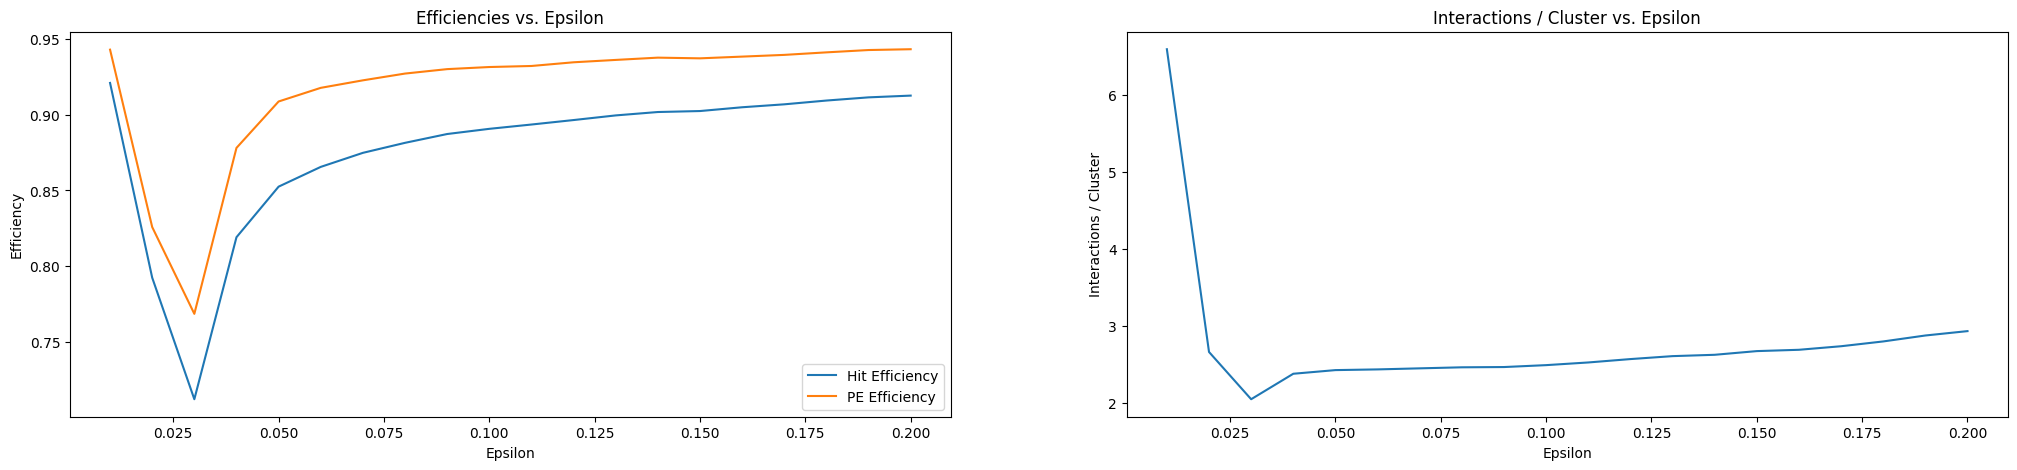

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(25, 5)) 


axes[0].plot(epsilons, avg_hit_eff, label = 'Hit Efficiency')
axes[0].plot(epsilons, avg_PE_eff, label = 'PE Efficiency')
axes[0].set_title("Efficiencies vs. Epsilon")
axes[0].set_xlabel("Epsilon")
axes[0].set_ylabel("Efficiency")
axes[0].legend()


axes[1].plot(epsilons, avg_occupancy)
axes[1].set_title("Interactions / Cluster vs. Epsilon")
axes[1].set_xlabel("Epsilon")
axes[1].set_ylabel("Interactions / Cluster")

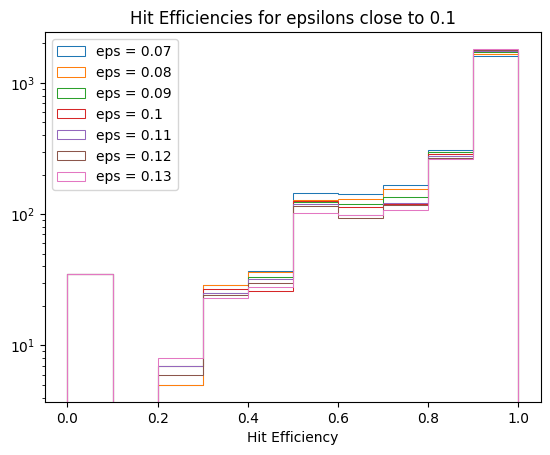

In [45]:
#Group hist for hits
for i, eps in enumerate(epsilons):
    if (0.06 < eps < 0.140):
        plt.hist(hit_eff_all[i], label = f'eps = {eps}', histtype = 'step', linewidth=0.75)
        plt.xlabel("Hit Efficiency")
        plt.title("Hit Efficiencies for epsilons close to 0.1")
        plt.yscale('log')
        plt.legend()

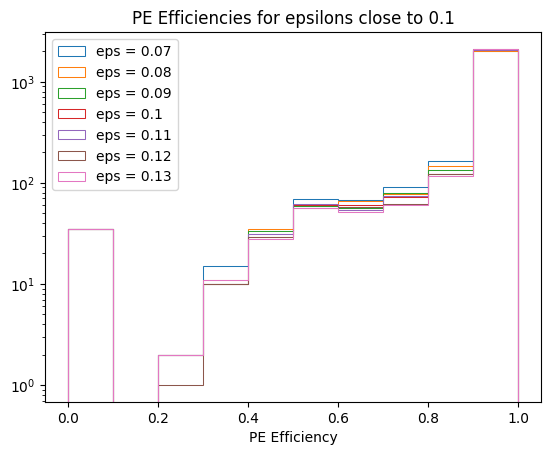

In [46]:
#Group hist for PEs
for i, eps in enumerate(epsilons):
    if (0.06 < eps < 0.140):
        plt.hist(PE_eff_all[i], label = f'eps = {eps}', histtype = 'step', linewidth=0.75)
        plt.xlabel("PE Efficiency")
        plt.title("PE Efficiencies for epsilons close to 0.1")
        plt.yscale('log')
        plt.legend()